In [40]:
import gymnasium as gym
from gymnasium import spaces
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
from matplotlib.colors import ListedColormap
from PIL import Image

In [60]:
# ACtual working code
class GridEnv(gym.Env):
    metadata = {"render.modes": ["human"]}


    def __init__(self, env_type):

        self.env_type = env_type
        self.slip_prob = 0.05
        self.observation_space = spaces.Box(low=0.0, high=1.0, shape=(36,), dtype=np.float32)
        self.action_space = spaces.Discrete(6)

        # Max iterations the agent has to traverse the env.
        self.max_timesteps = 70

        # This is teh Agent's Initial position: at 0,0 : for now it is start of the grid.
        self.agent_pos = [0, 0]

        # THis is the goal position: at 5,5: Where the agent has to deliver the package.
        self.goal_pos = (5, 5)

        # This is the obstacle where agent cannot go.
        self.obstacle_pos = (3, 3)

        self.state = np.zeros((6, 6))

        # This where the iteration will start from
        self.timestep = 0
        self.state[tuple(self.agent_pos)] = 1
        self.state[tuple(self.goal_pos)] = 0.5

        # We also need a location for a package which agent will pick up from which is different from the obstacle (TA confirmed).
        self.package_pos = [2, 2]

        # Initially Agent will not have the package, so we will keep that flag as Flase
        self.has_package = False

        # Image Loading
        self.agent_img = plt.imread("../assets/Agent.jpeg")
        self.agent_with_package_img = plt.imread("../assets/Agent_with_Package.png")

        self.goal_img = plt.imread("../assets/Goal.jpeg")
        self.package_img = plt.imread("../assets/package.png")
        self.obstacle_img = plt.imread("../assets/Obstacle.png")


    def reset(self, **kwargs):

        self.timestep = 0
        self.agent_pos = [0, 0]
        self.obstacle_pos = (3, 3)

        self.state = np.zeros((6, 6))
        self.state[tuple(self.agent_pos)] = 1.0
        self.state[tuple(self.goal_pos)] = 0.5
        observation = self.state.flatten()

        self.has_package = False

        info = {}

        return observation, info

    def _draw_image(self, ax, img, x, y, zoom=0.16):
        from matplotlib.offsetbox import OffsetImage, AnnotationBbox

        im = OffsetImage(img, zoom=zoom)
        ab = AnnotationBbox(im, (y, x), frameon=False)
        ax.add_artist(ab)




    def check_package(self, pos):
        # pass
        # If pos [x, y] == self.package_pos:
        #    return True
        # Else:
        #    return False

        if pos == self.package_pos:
            return True
        else:
            return False



    def check_obstacle(self, pos):
        # pass
        # If pos [x, y] == self.obstacle_pos:
        #    return True
        # Else:
        #    return False

        if tuple(pos) == self.obstacle_pos:
            return True
        else:
            return False

    def check_goal(self, pos):
        # pass
        if tuple(pos) == self.goal_pos:
            return True
        else:
            return False

    def resolve_reward(self, pos, has_package):
        # pass

        if self.check_obstacle(pos):
            return -20

        elif self.check_goal(pos):
            if has_package:
                return 100
            else:
                # If the agent reached goal without package.
                return -5
        else:
            return -1

    def step(self, action):
        reward = 0
        # new_pos = self.agent_pos.copy()
        self.timestep += 1

        # We have action here as an input. Before we exectue that action, I think we need to do some validations on it.
        # If that action is possible or not, if possible then whether it has a packagae on it or not.
        # If we have a package in that position, is our robot, free to pick that up or not.
        # If we dont have package we will have to pick up the package and change teh tha flag as well.

        if self.env_type == "Stochastic" and np.random.rand() < self.slip_prob:
            action = self.action_space.sample()

        x = self.agent_pos[0]
        y = self.agent_pos[1]

        new_pos = self.agent_pos.copy()

        if action == 0:
            # Generate a random number:
            # If that number < 95: then:
            #   new_pos[0] += 1
            # elif number < 96.5: then new_pos[0] += 1
            # elif number < 98: then new_pos

            new_pos[0] += 1

        # go up on 1
        if action == 1:
          new_pos[0] -= 1


        # go left on 2
        if action == 2:
            new_pos[1] -= 1

        # go right on 3
        if action == 3:
            new_pos[1] += 1

        if action == 4:
            if not self.has_package and self.check_package(self.agent_pos):
                self.has_package = True
                reward += self.resolve_reward(new_pos, self.has_package)

        if action == 5:
            if self.has_package and self.check_goal(self.agent_pos):
                self.has_package = False
                reward += self.resolve_reward(new_pos, self.has_package)
                terminated = True

        # Keep in bounds the robot
        new_pos[0] = int(np.clip(new_pos[0], 0, 5))
        new_pos[1] = int(np.clip(new_pos[1], 0, 5))

        if self.check_obstacle(new_pos):

            # Obstacle Found.
            # Then we dont move.
            # self.has_package = self.check_package([x+1, y])
            # Reward = -20
            reward += self.resolve_reward(new_pos, self.has_package)

        else:
            self.agent_pos = new_pos
            reward += self.resolve_reward(new_pos, self.has_package)

        if not self.has_package and self.check_package(new_pos):
            # Package Found in new position.
            # Reward = +25 on pickup
            self.has_package = self.check_package(new_pos)
            reward += self.resolve_reward(new_pos, self.has_package)

        terminated = False
        if self.check_goal(new_pos):
            # Check if GOAL is the next position.
            if self.has_package:
                # Check if we have package.
                terminated = True
                # Reward = +100
                # Revisit this again...Reward was doubling because of this!!!!
                # reward += self.resolve_reward(new_pos, self.has_package)

        ########################################################################
        # if action == 0: # Down
        #     # pass
        #     x = self.agent_pos[0]
        #     y = self.agent_pos[1]
        #     if self.check_obstacle([x+1, y]):
        #         # Obstacle Found.
        #         # Then we dont move.
        #         self.has_package = self.check_package([x+1, y])
        #         # Reward = -20
        #         reward += self.resolve_reward([x+1, y], self.has_package)

        #     else:
        #         # No Obstacle.
        #         # Move to new position.
        #         new_pos[0] += 1
        #         # reward = 0
        #         # Check if new pos has package.
        #         self.has_package = self.check_package([x+1, y])

        #         # Package Found.
        #         if self.has_package:
        #             # Reward = +25
        #             reward += self.resolve_reward([x+1, y], self.has_package)
        #         else:
        #             # Package Not Found.
        #             reward += self.resolve_reward([x+1, y], self.has_package)



        #     # Current [x, y] | next pos as per action: [x + 1, y] => if this has i.e. = self.obstacle_pos:


        #     # Else we move to new pos

        # elif action == 1: # Up:
        #     pass
        #     # Check if there is an obsactle below or if it is package. If package and no obstacle => +25
        #     # Current [x, y] | next pos as per action: [x - 1, y] => if this has i.e. = self.obstacle_pos:
        #         # Then we dont move.

        #     # Else we move to new pos

        # elif action == 2: # Left:
        #     pass
        #     # Check if there is an obsactle below or if it is package. If package and no obstacle => +25
        #     # Current [x, y] | next pos as per action: [x, y-1] => if this has i.e. = self.obstacle_pos:
        #         # Then we dont move.

        #     # Else we move to new pos

        # elif action == 3: # Right:
        #     pass
        #     # Check if there is an obsactle below or if it is package. If package and no obstacle => +25
        #     # Current [x, y] | next pos as per action: [x, y+1] => if this has i.e. = self.obstacle:
        #         # Then we dont move.

        #     # Else we move to new pos




        # # If x, y == goal and has_package == True:
        # #   Reward respective points and Drop package. Terminate

        # # if x, y == goal and has_package == False:
        # #   Need to think on what can be done.

        # # elif no obstacle and if not has_package and is_pick == True:
        # #    Go in that direction. Get the respective reward

        # # go down on 0
        # if action == 0:
        #     new_pos[0] += 1

        # # go up on 1
        # if action == 1:
        #   new_pos[0] -= 1


        # # go left on 2
        # if action == 2:
        #     new_pos[1] -= 1

        # # go right on 3
        # if action == 3:
        #   new_pos[1] += 1

        # # Keep in bounds the robot
        # new_pos[0] = int(np.clip(new_pos[0], 0, 5))
        # new_pos[1] = int(np.clip(new_pos[1], 0, 5))

        # if tuple(new_pos) != self.obstacle_pos:
        #     self.agent_pos = new_pos

        ########################################################################
        new_pos[0] = int(np.clip(new_pos[0], 0, 5))
        new_pos[1] = int(np.clip(new_pos[1], 0, 5))

        self.state = np.zeros((6, 6))
        self.state[tuple(self.agent_pos)] = 1.0
        self.state[tuple(self.goal_pos)] = 0.5
        observation = self.state.flatten()
        # reward = 0

        # terminated = tuple(self.agent_pos) == self.goal_pos
        # if terminated:
        #     reward = 1
        # else:
        #     reward = 0

        # self.timestep += 1
        truncated = self.timestep >= self.max_timesteps
        info = {}

        return observation, reward, terminated, truncated, info


    def render(self):
        fig, ax = plt.subplots(figsize=(6, 6))

        agent_x_cord, agent_y_cord = self.agent_pos

        # Base empty grid
        grid = np.zeros((6, 6))
        ax.imshow(grid, cmap=ListedColormap(['white']))

        self._draw_image(ax, self.goal_img, self.goal_pos[0], self.goal_pos[1], zoom=0.16)

        self._draw_image(ax, self.obstacle_img, self.obstacle_pos[0], self.obstacle_pos[1], zoom=0.16)

        if not self.has_package:
            self._draw_image(ax, self.package_img, self.package_pos[0], self.package_pos[1], zoom=0.14)

        if self.has_package:
            self._draw_image(ax, self.agent_with_package_img, agent_x_cord, agent_y_cord, zoom=0.04)
        else:
            self._draw_image(ax, self.agent_img, agent_x_cord, agent_y_cord, zoom=0.16)


        # Grid styling
        ax.set_xticks(np.arange(-0.5, 6, 1))
        ax.set_yticks(np.arange(-0.5, 6, 1))
        ax.set_xticklabels([])
        ax.set_yticklabels([])
        ax.grid(True)
        ax.set_title("GRID ENVIRONMENT")
        plt.show()



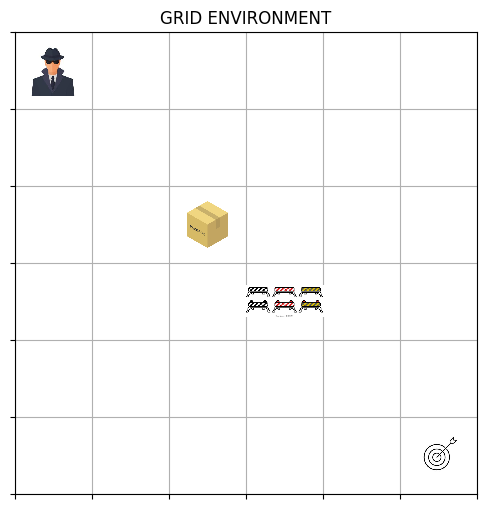

Action: 4 | Reward_total:-1 | TER: False | TRUN: False


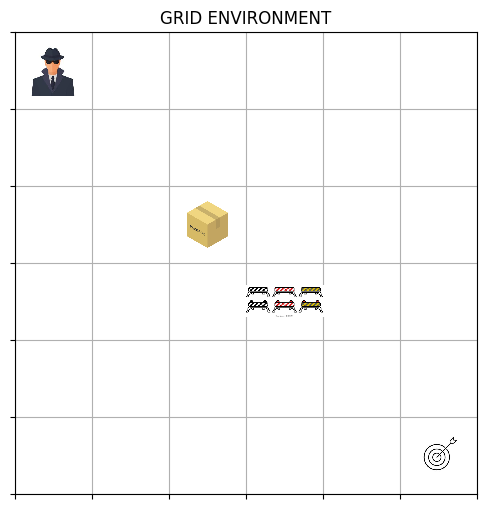

Action: 2 | Reward_total:-2 | TER: False | TRUN: False


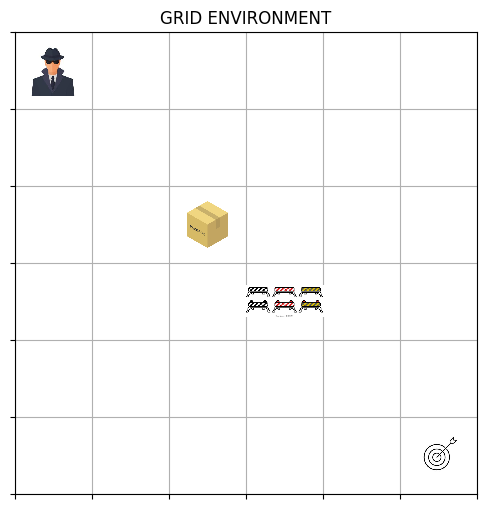

Action: 4 | Reward_total:-3 | TER: False | TRUN: False


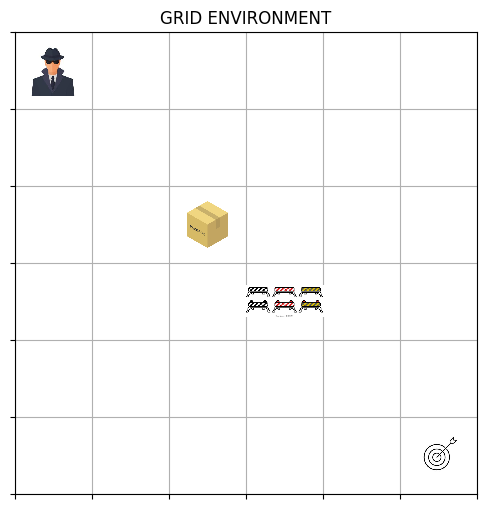

Action: 1 | Reward_total:-4 | TER: False | TRUN: False


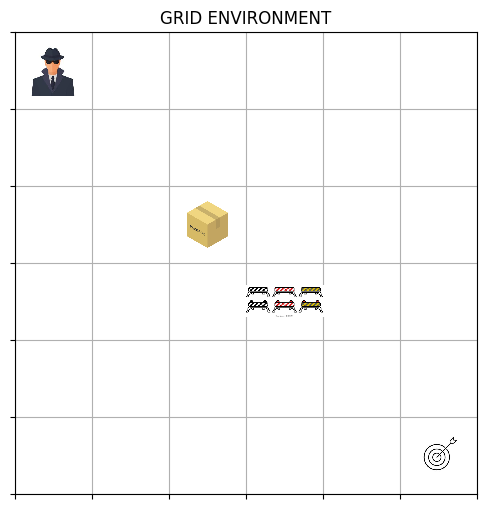

Action: 3 | Reward_total:-5 | TER: False | TRUN: False


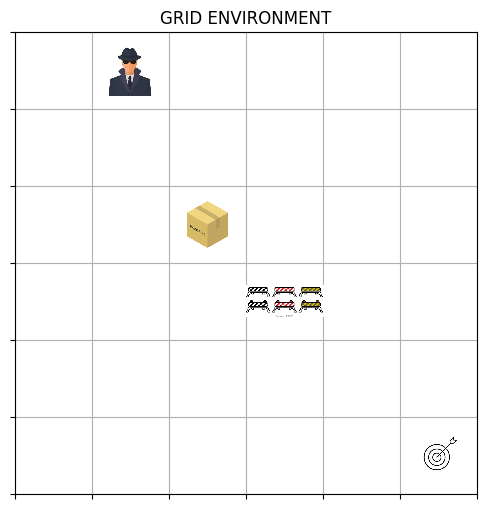

Action: 4 | Reward_total:-6 | TER: False | TRUN: False


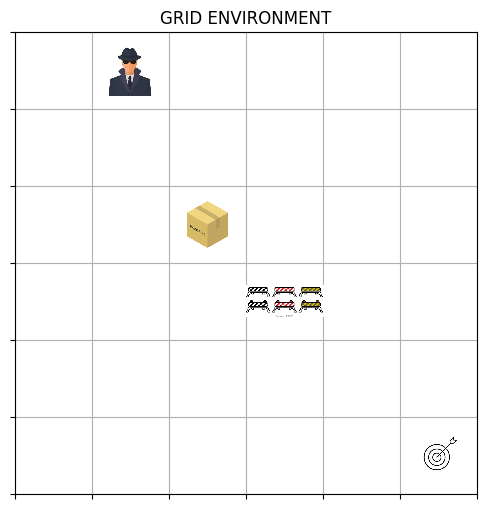

Action: 1 | Reward_total:-7 | TER: False | TRUN: False


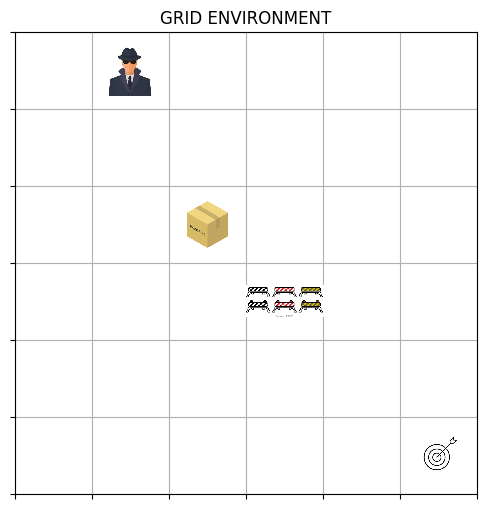

Action: 0 | Reward_total:-8 | TER: False | TRUN: False


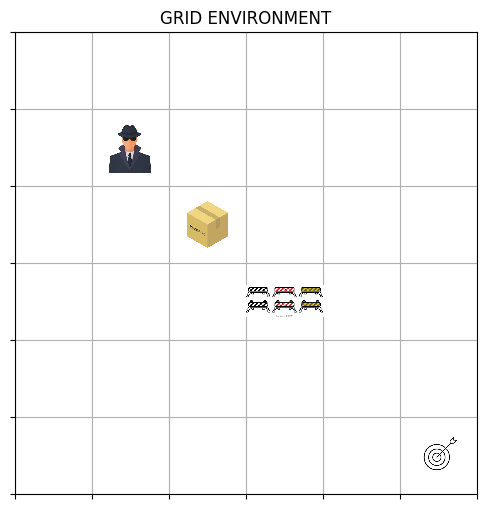

Action: 1 | Reward_total:-9 | TER: False | TRUN: False


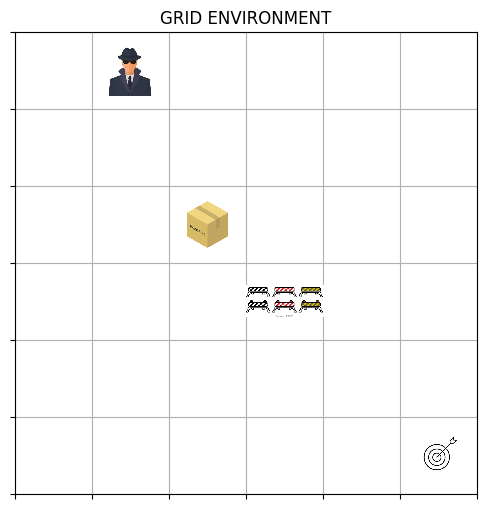

Action: 0 | Reward_total:-10 | TER: False | TRUN: False


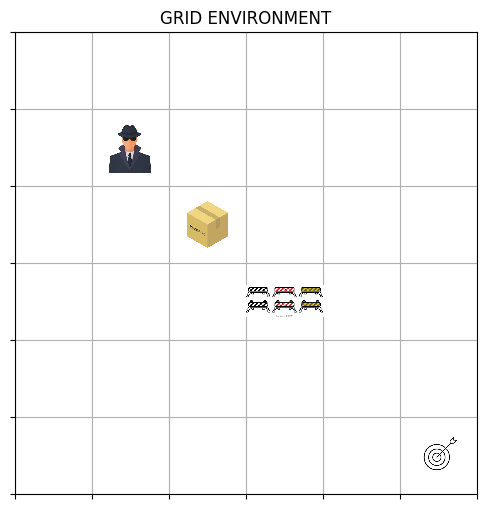

Action: 5 | Reward_total:-11 | TER: False | TRUN: False


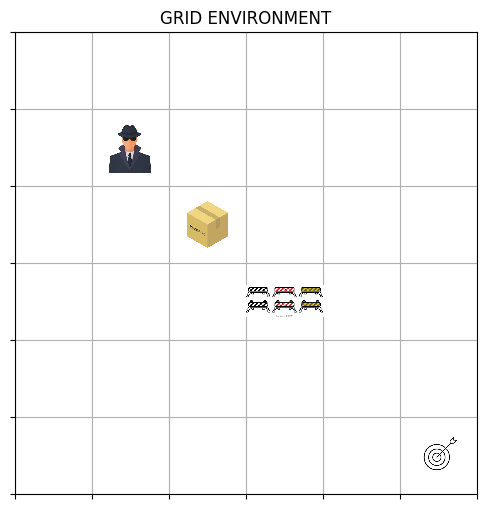

Action: 2 | Reward_total:-12 | TER: False | TRUN: False


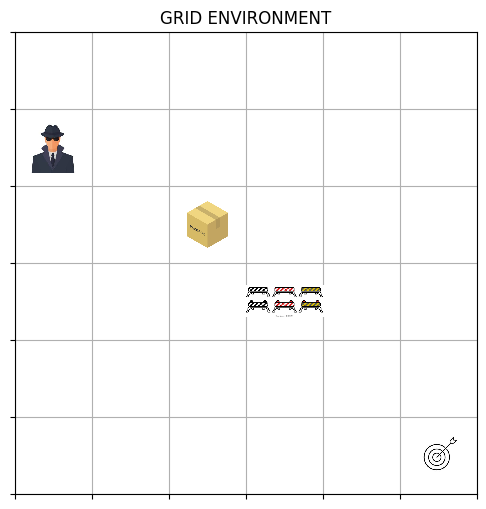

Action: 4 | Reward_total:-13 | TER: False | TRUN: False


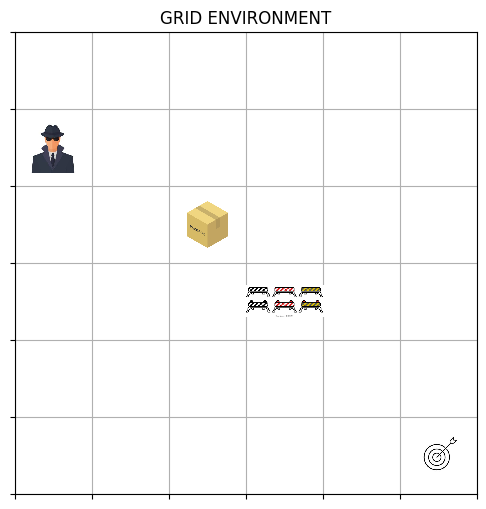

Action: 2 | Reward_total:-14 | TER: False | TRUN: False


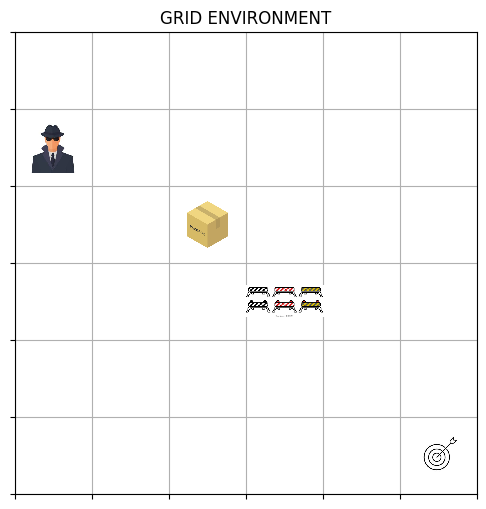

Action: 3 | Reward_total:-15 | TER: False | TRUN: False


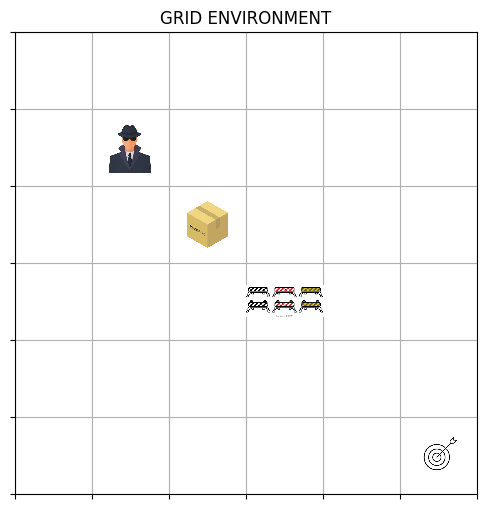

Action: 1 | Reward_total:-16 | TER: False | TRUN: False


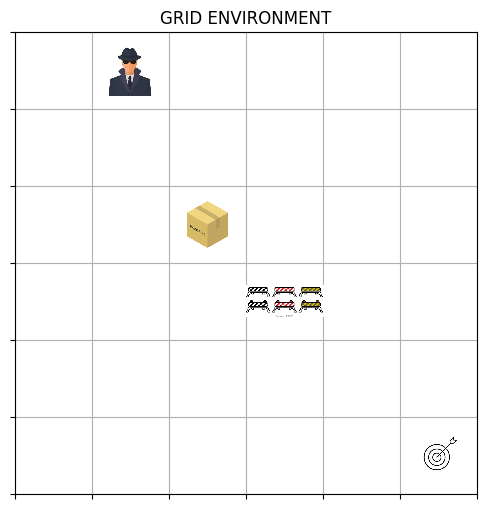

Action: 1 | Reward_total:-17 | TER: False | TRUN: False


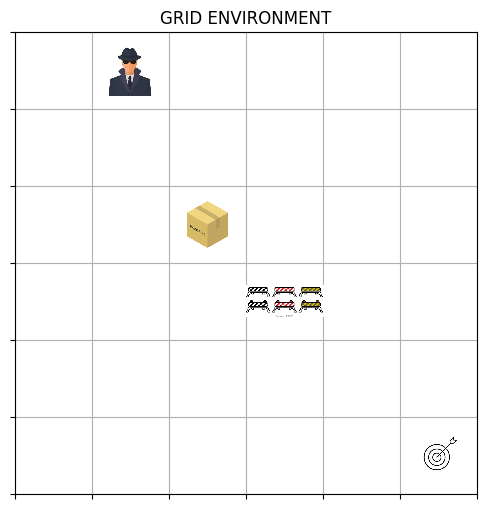

Action: 2 | Reward_total:-18 | TER: False | TRUN: False


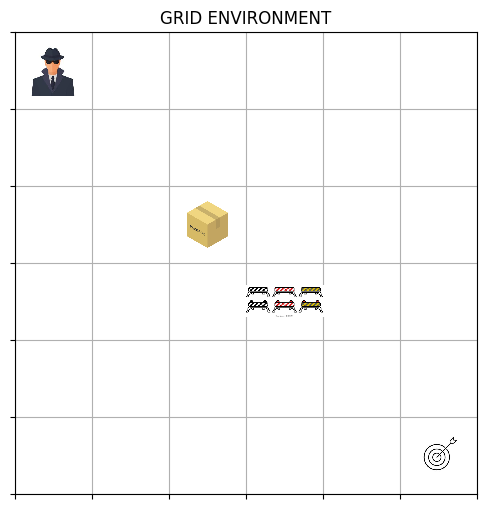

Action: 3 | Reward_total:-19 | TER: False | TRUN: False


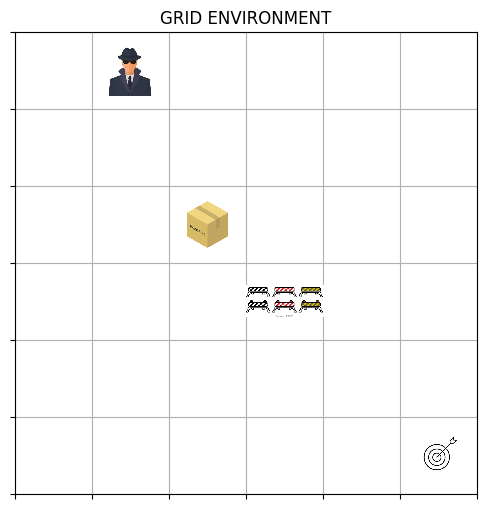

Action: 1 | Reward_total:-20 | TER: False | TRUN: False


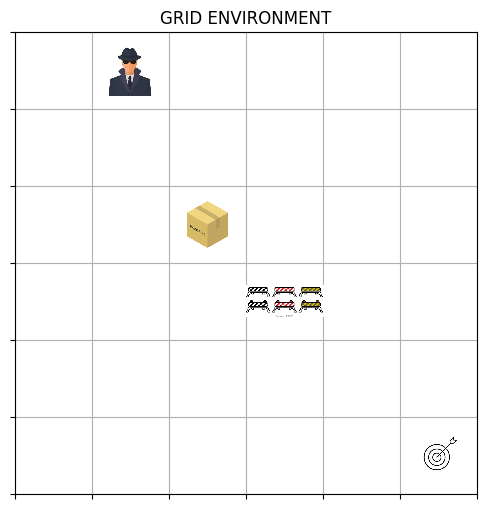

Action: 1 | Reward_total:-21 | TER: False | TRUN: False


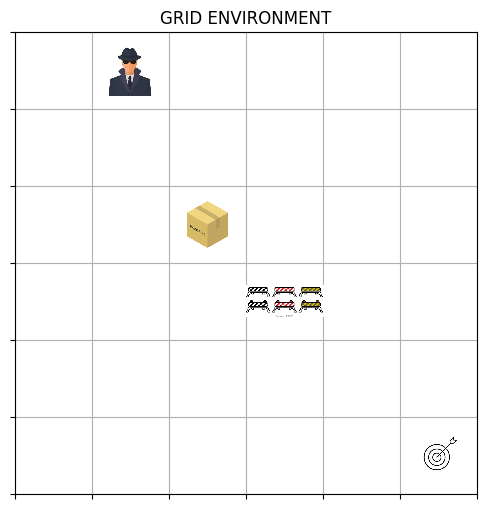

Action: 0 | Reward_total:-22 | TER: False | TRUN: False


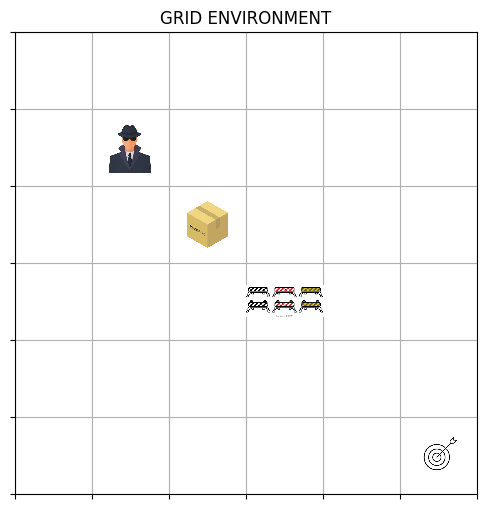

Action: 3 | Reward_total:-23 | TER: False | TRUN: False


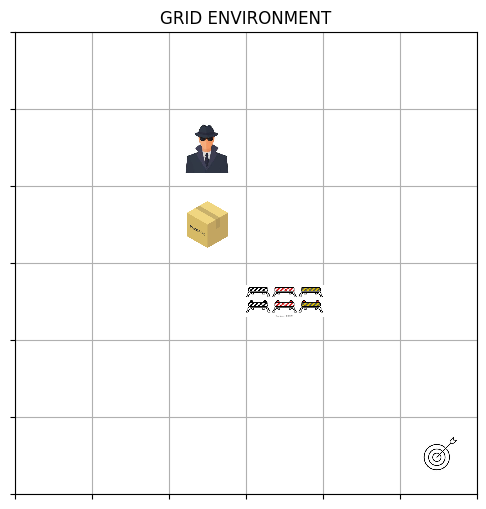

Action: 0 | Reward_total:-25 | TER: False | TRUN: False


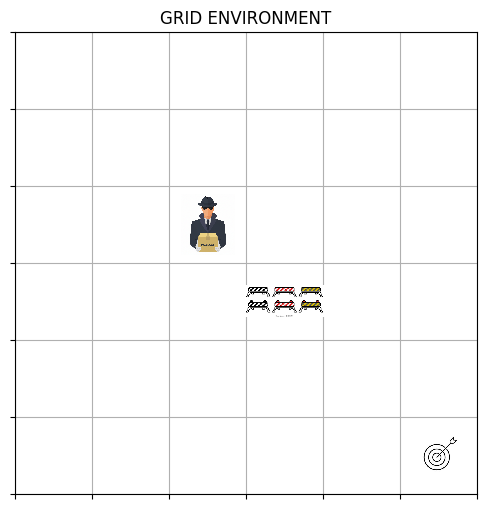

Action: 3 | Reward_total:-26 | TER: False | TRUN: False


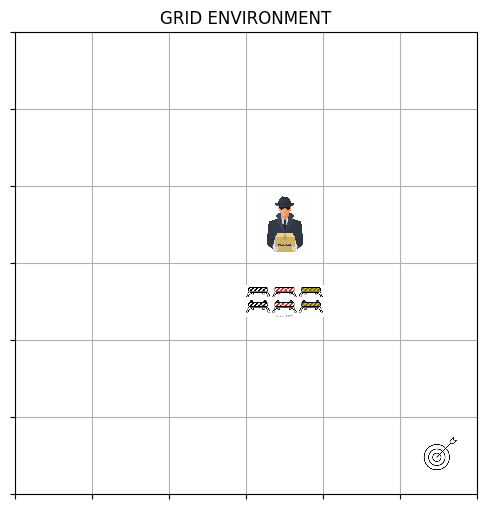

Action: 2 | Reward_total:-27 | TER: False | TRUN: False


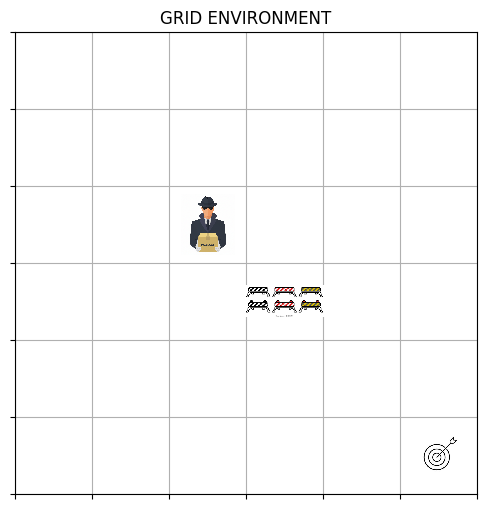

Action: 0 | Reward_total:-28 | TER: False | TRUN: False


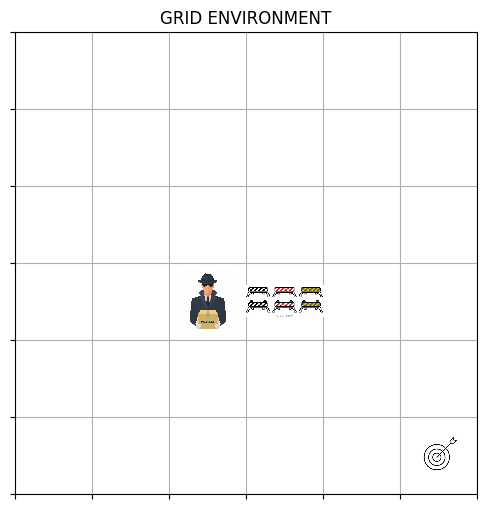

Action: 5 | Reward_total:-29 | TER: False | TRUN: False


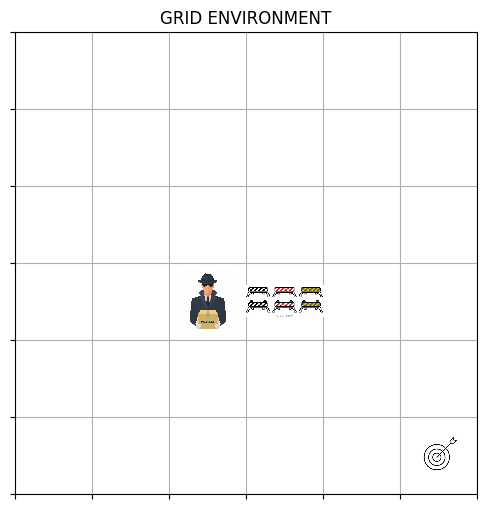

Action: 1 | Reward_total:-30 | TER: False | TRUN: False


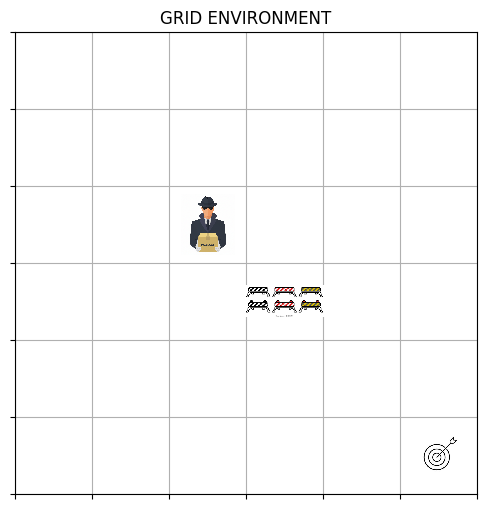

Action: 5 | Reward_total:-31 | TER: False | TRUN: False


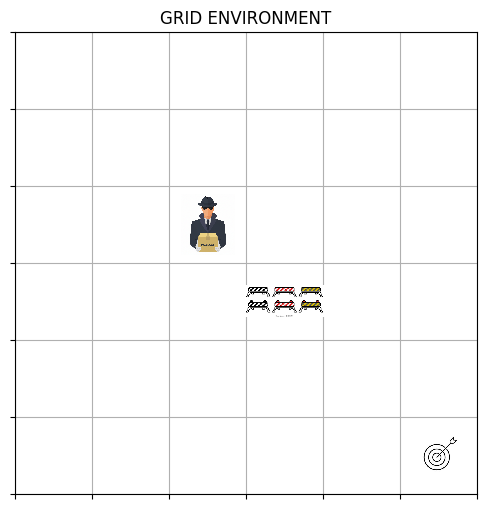

Action: 3 | Reward_total:-32 | TER: False | TRUN: False


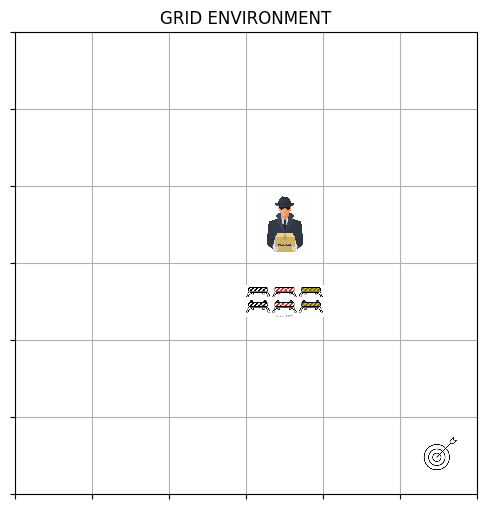

Action: 1 | Reward_total:-33 | TER: False | TRUN: False


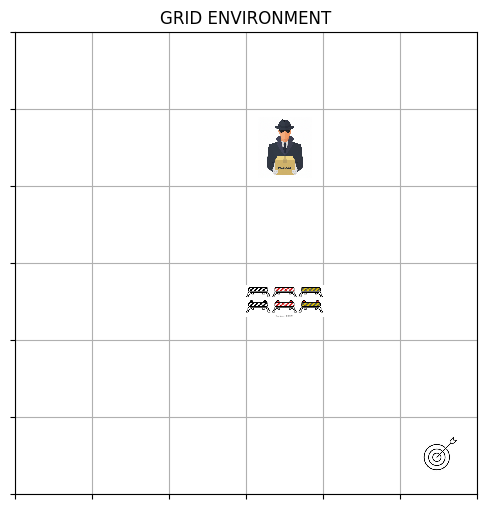

Action: 0 | Reward_total:-34 | TER: False | TRUN: False


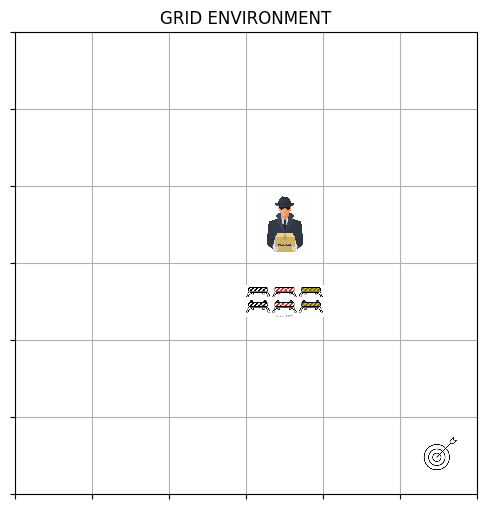

Action: 3 | Reward_total:-35 | TER: False | TRUN: False


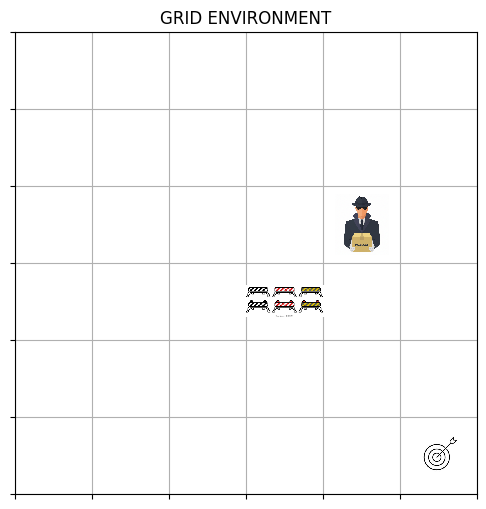

Action: 5 | Reward_total:-36 | TER: False | TRUN: False


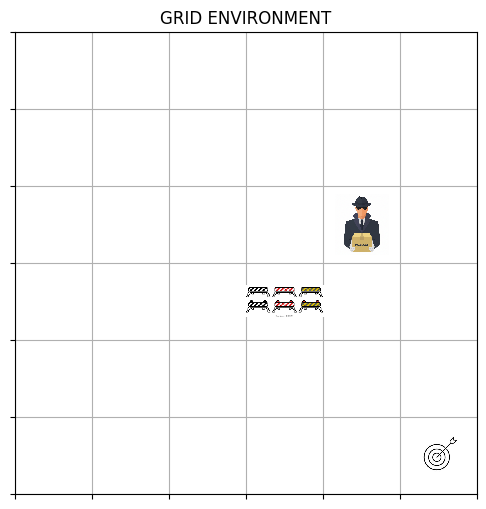

Action: 4 | Reward_total:-37 | TER: False | TRUN: False


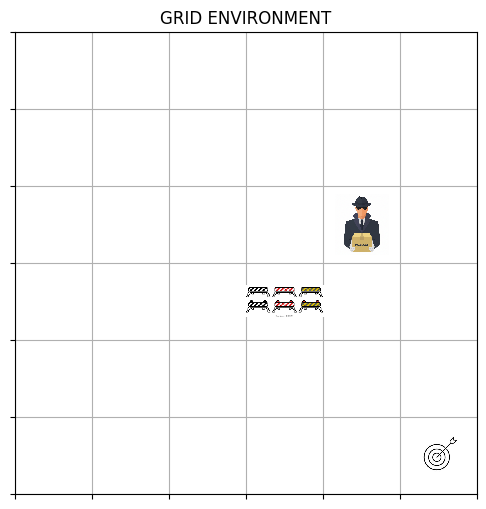

Action: 5 | Reward_total:-38 | TER: False | TRUN: False


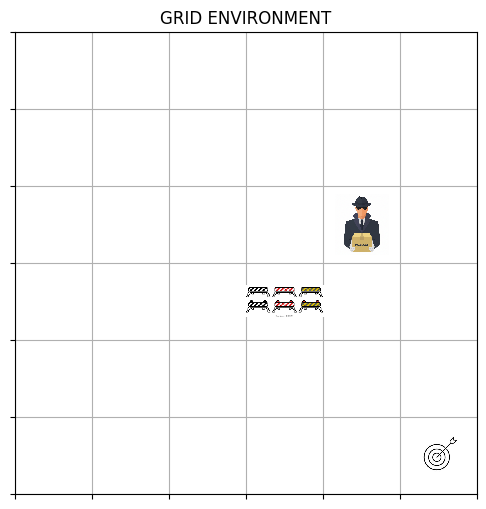

Action: 4 | Reward_total:-39 | TER: False | TRUN: False


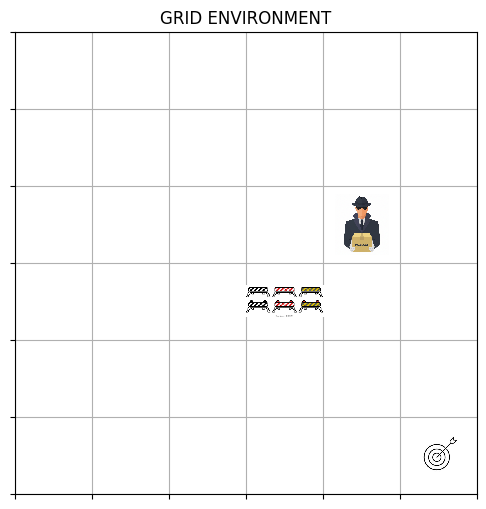

Action: 0 | Reward_total:-40 | TER: False | TRUN: False


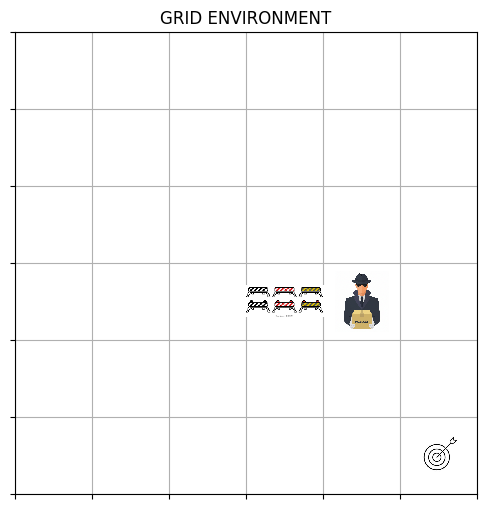

Action: 3 | Reward_total:-41 | TER: False | TRUN: False


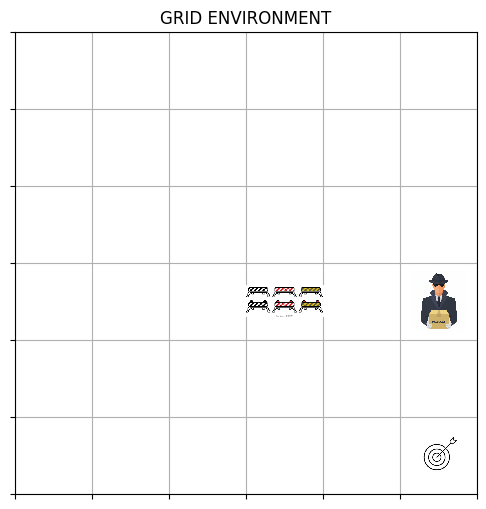

Action: 4 | Reward_total:-42 | TER: False | TRUN: False


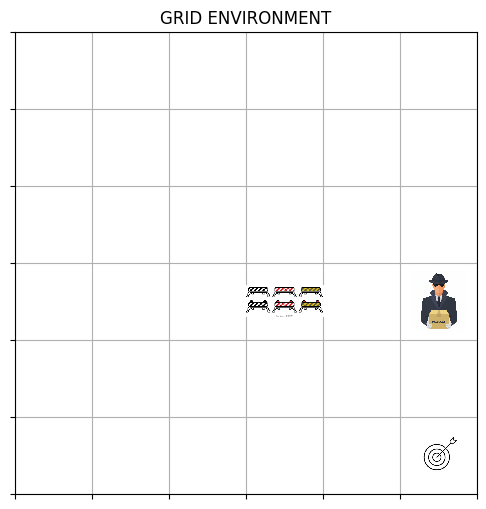

Action: 4 | Reward_total:-43 | TER: False | TRUN: False


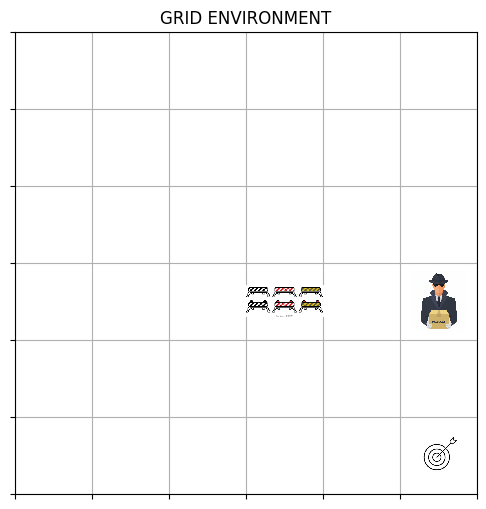

Action: 1 | Reward_total:-44 | TER: False | TRUN: False


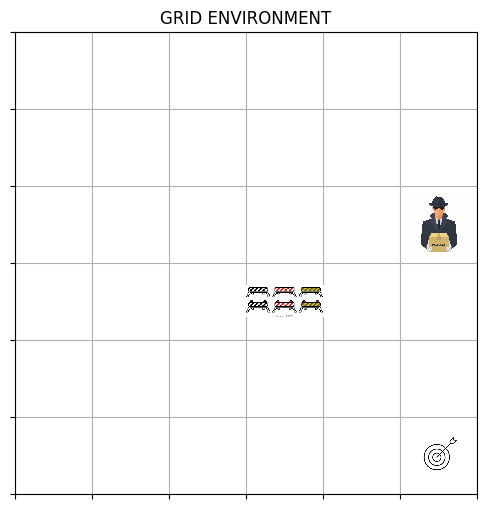

Action: 4 | Reward_total:-45 | TER: False | TRUN: False


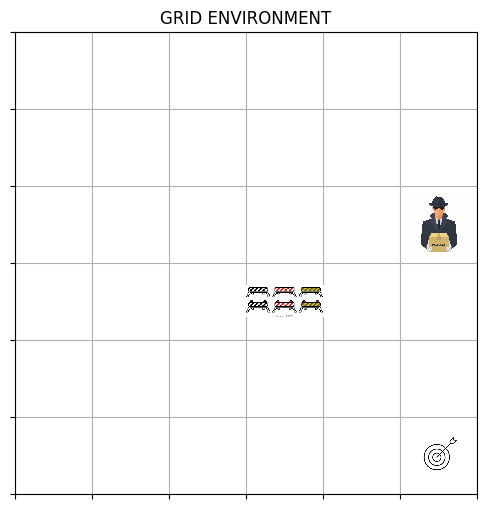

Action: 0 | Reward_total:-46 | TER: False | TRUN: False


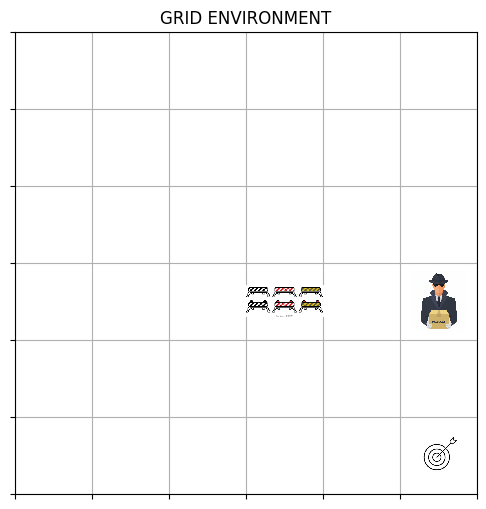

Action: 3 | Reward_total:-47 | TER: False | TRUN: False


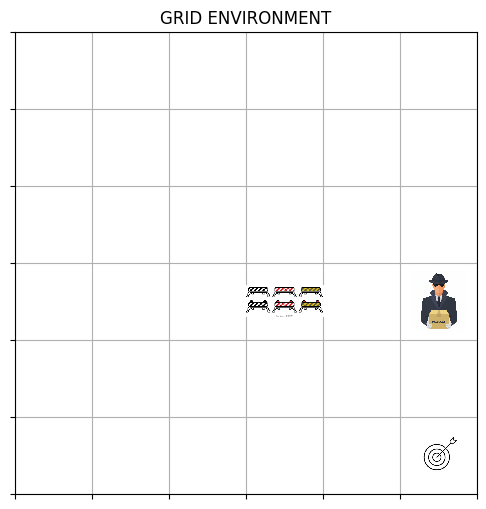

Action: 0 | Reward_total:-48 | TER: False | TRUN: False


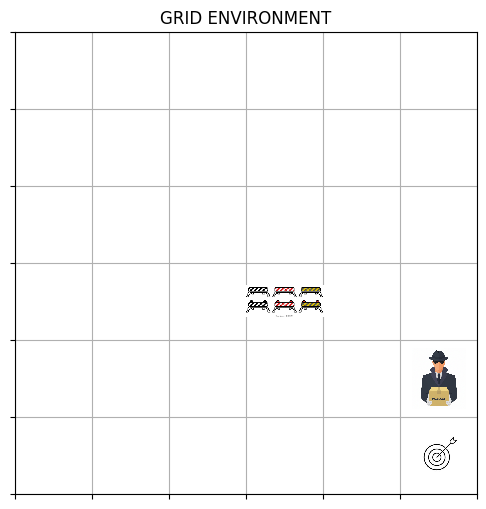

Action: 5 | Reward_total:-49 | TER: False | TRUN: False


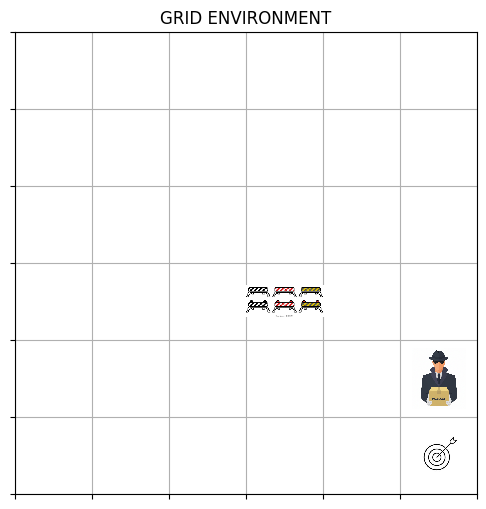

Action: 1 | Reward_total:-50 | TER: False | TRUN: False


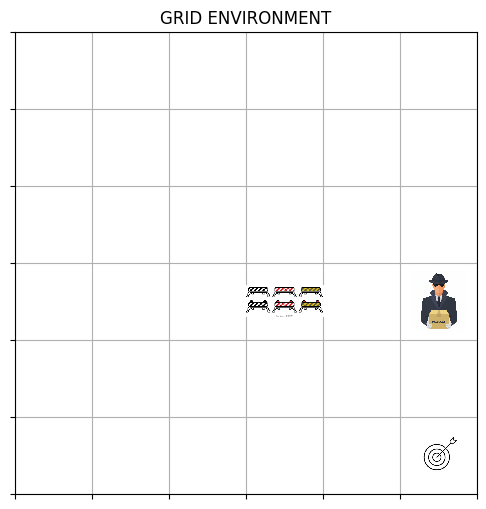

Action: 3 | Reward_total:-51 | TER: False | TRUN: False


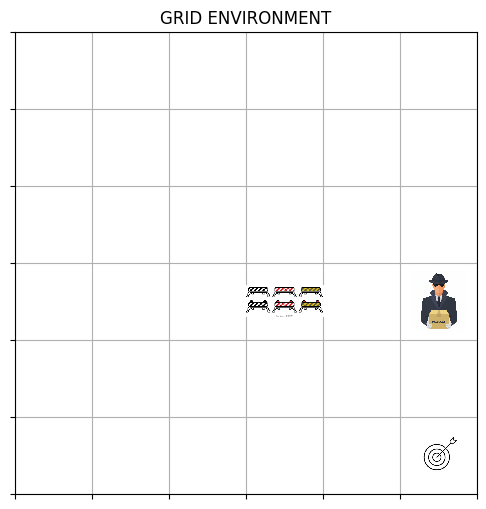

Action: 5 | Reward_total:-52 | TER: False | TRUN: False


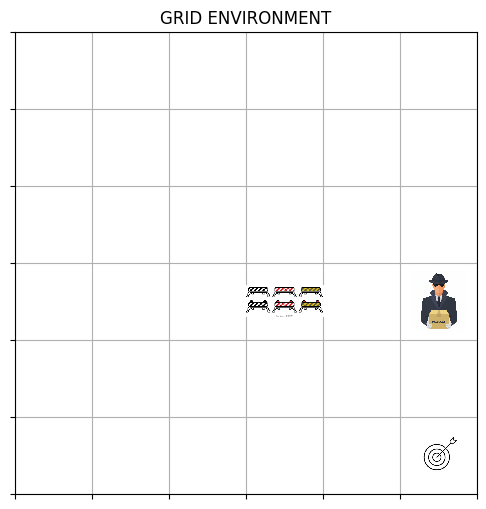

Action: 0 | Reward_total:-53 | TER: False | TRUN: False


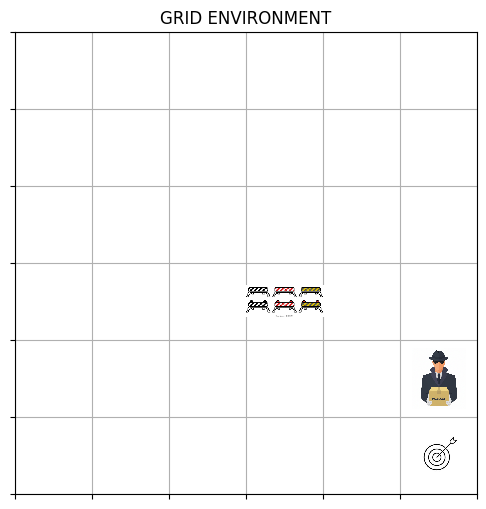

Action: 4 | Reward_total:-54 | TER: False | TRUN: False


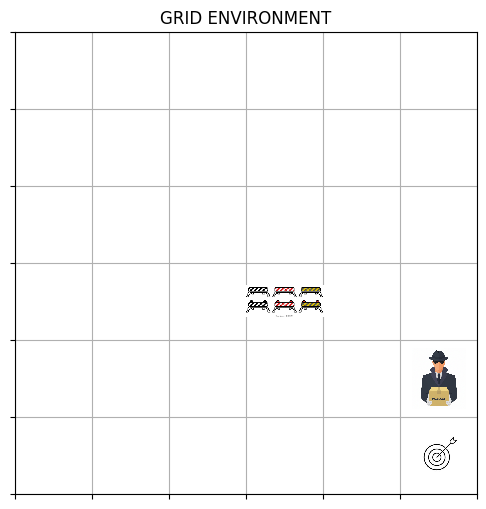

Action: 1 | Reward_total:-55 | TER: False | TRUN: False


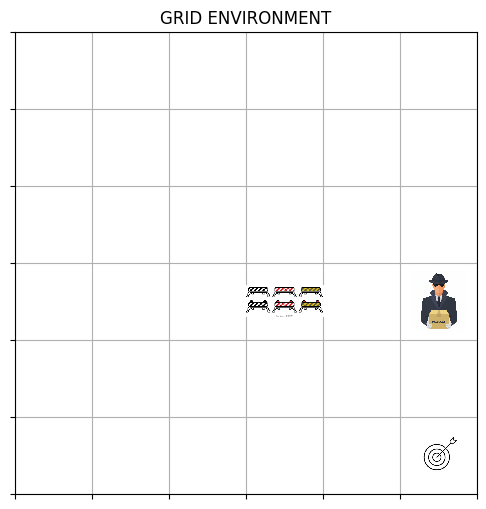

Action: 2 | Reward_total:-56 | TER: False | TRUN: False


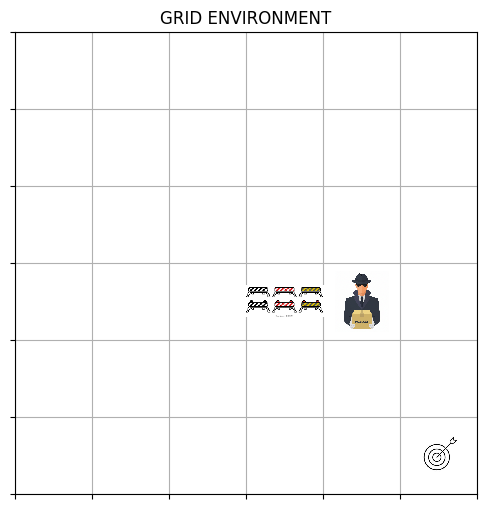

Action: 1 | Reward_total:-57 | TER: False | TRUN: False


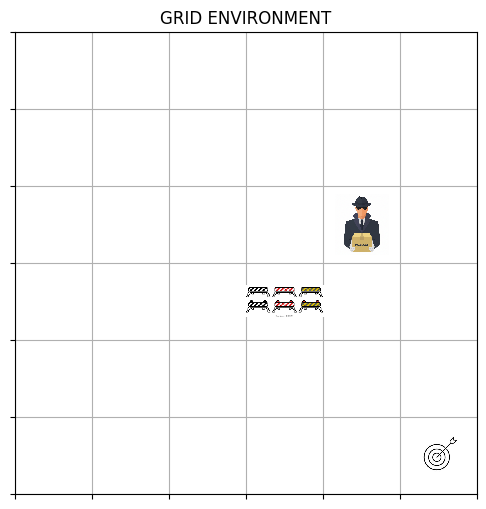

Action: 3 | Reward_total:-58 | TER: False | TRUN: False


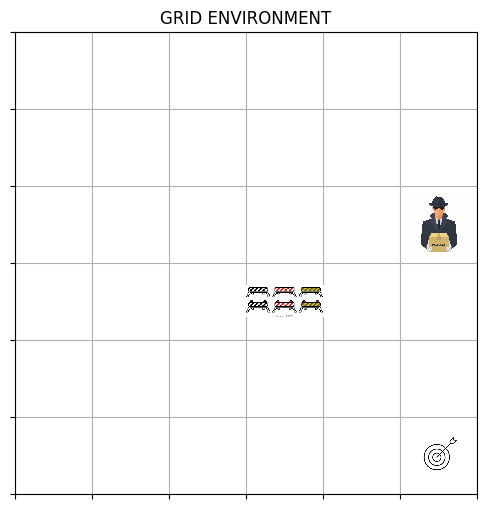

Action: 5 | Reward_total:-59 | TER: False | TRUN: False


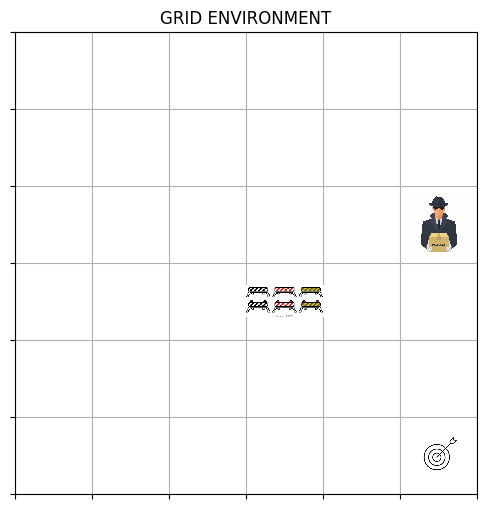

Action: 5 | Reward_total:-60 | TER: False | TRUN: False


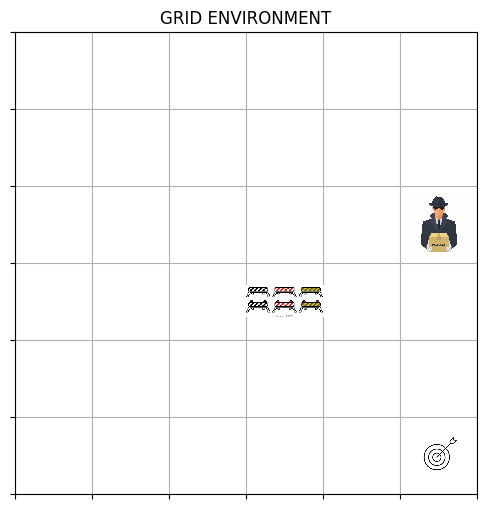

Action: 0 | Reward_total:-61 | TER: False | TRUN: False


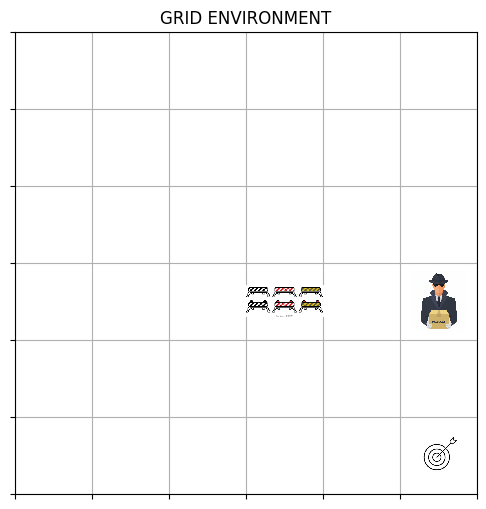

Action: 0 | Reward_total:-62 | TER: False | TRUN: False


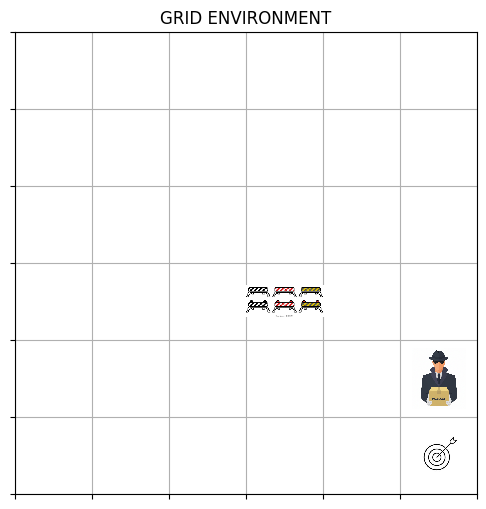

Action: 3 | Reward_total:-63 | TER: False | TRUN: False


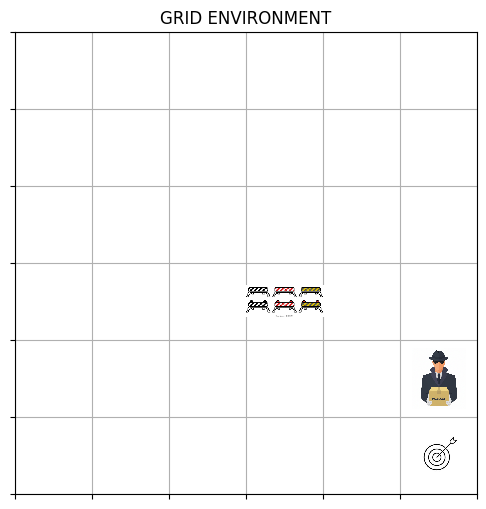

Action: 2 | Reward_total:-64 | TER: False | TRUN: False


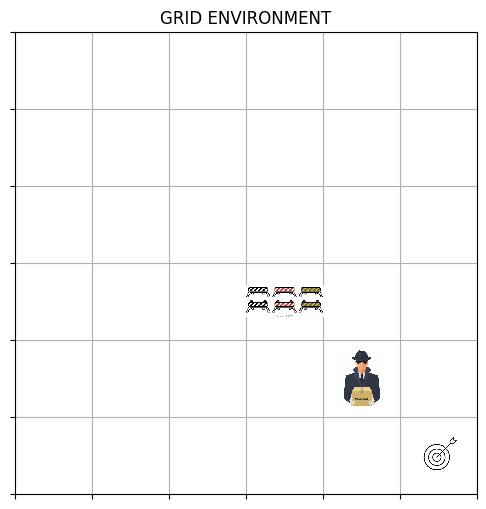

Action: 0 | Reward_total:-65 | TER: False | TRUN: False


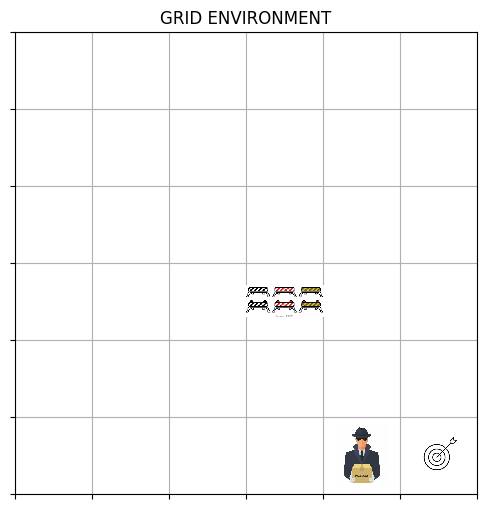

Action: 0 | Reward_total:-66 | TER: False | TRUN: False


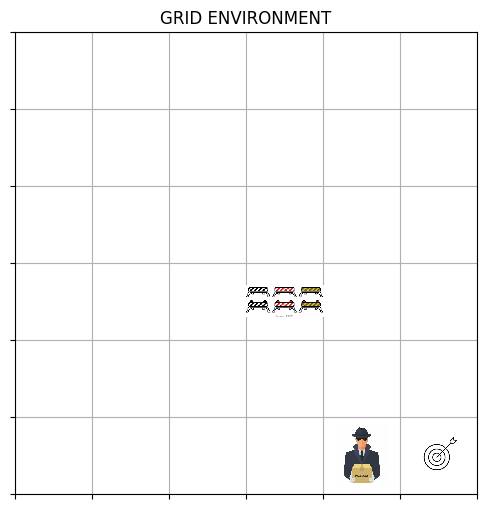

Action: 0 | Reward_total:-67 | TER: False | TRUN: False


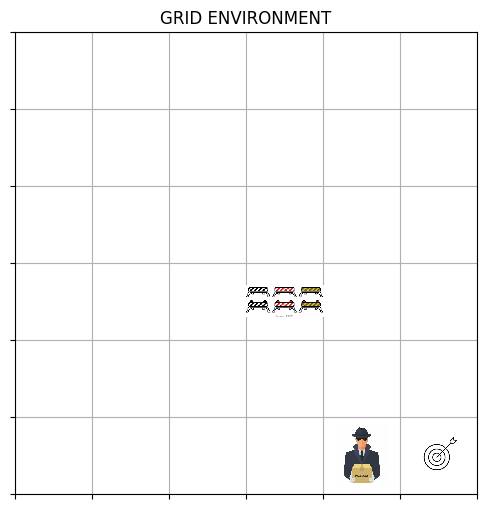

Action: 1 | Reward_total:-68 | TER: False | TRUN: False


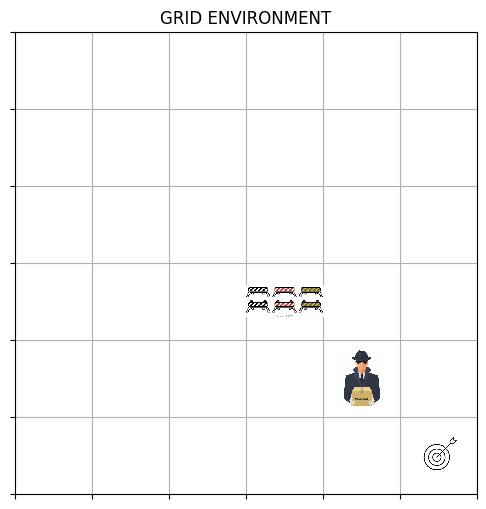

Action: 3 | Reward_total:-69 | TER: False | TRUN: False


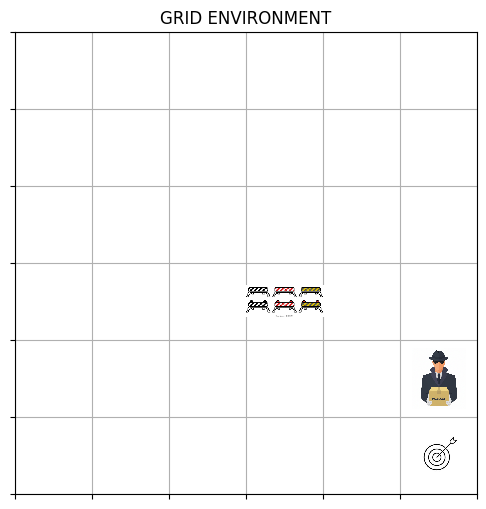

Action: 4 | Reward_total:-70 | TER: False | TRUN: False


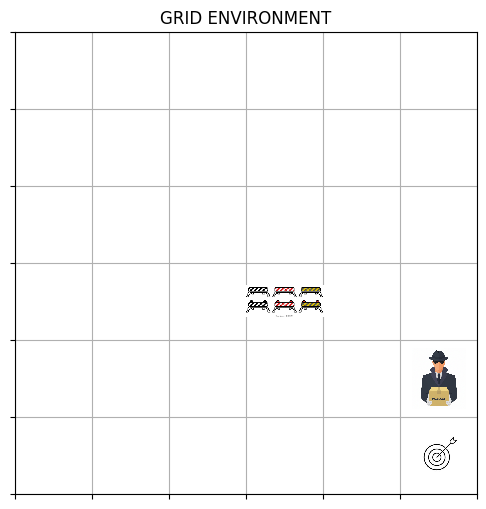

Action: 2 | Reward_total:-71 | TER: False | TRUN: True


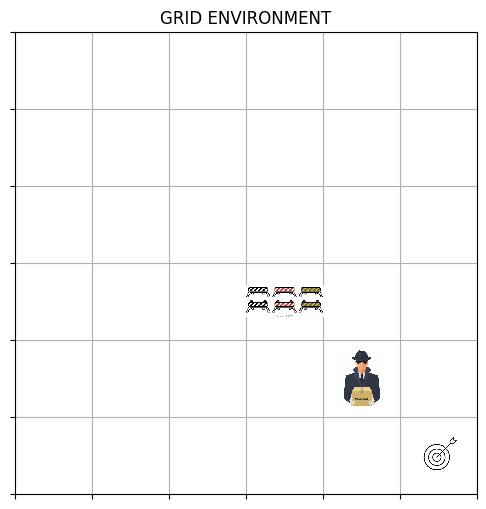

In [63]:
class Agent:
    def __init__(self, env):
        self.env = env

    def choose_action(self):
        return self.env.action_space.sample()


if __name__ == "__main__":
    # env = GridEnv("Stochastic")
    env = GridEnv("Deterministic")
    agent = Agent(env)
    obs, info = env.reset()
    terminated, truncated = False, False

    env.render()
    total_reward = 0
    for i in range(400):
        action = agent.choose_action()
        obs, r, term, trunc, info = env.step(action)
        total_reward += r
        print(f"Action: {action} | Reward_total:{total_reward} | TER: {term} | TRUN: {trunc}")
        env.render()
        if term or trunc:
            break